In [2]:
import pandas as pd

df1 = pd.read_csv("results/results.csv")
df2 = pd.read_csv("results/results_temp05.csv")

merged = pd.concat([df1, df2], ignore_index=True)

merged.to_csv("results/results_merged.csv", index=False)

print("Merged rows:", len(merged))

Merged rows: 8000


In [3]:
merged.groupby(["model","temperature","prompt_version"]).size()

model         temperature  prompt_version
gpt-4.1       0.5          absolute          1000
gpt-4.1-mini  0.5          balance           1000
              1.0          absolute          3000
                           balance           1000
              1.5          absolute          1000
                           balance           1000
dtype: int64

In [4]:
import pandas as pd
import statsmodels.formula.api as smf

In [5]:
df = pd.read_csv("results/results_merged.csv")

In [6]:
df["domain"] = df["domain"].astype("category")
df["valence"] = df["valence"].astype("category")
df["prompt_version"] = df["prompt_version"].astype("category")
df["temperature"] = df["temperature"].astype("category")
df["model"] = df["model"].astype("category")

KeyError: 'domain'

In [7]:
df["domain"] = df["outcome_type"]

In [8]:
df["domain"] = df["domain"].astype("category")
df["valence"] = df["valence"].astype("category")
df["prompt_version"] = df["prompt_version"].astype("category")
df["temperature"] = df["temperature"].astype("category")
df["model"] = df["model"].astype("category")

KeyError: 'valence'

In [9]:
df["domain"] = df["outcome_type"]

def get_valence(c):
    if "gain" in c:
        return "gain"
    elif "neutral" in c:
        return "neutral"
    else:
        return "loss"

df["valence"] = df["condition"].apply(get_valence)

In [10]:
df[["condition", "outcome_type", "domain", "valence"]].head(10)

,condition,outcome_type,domain,valence
0,realized_loss_large,realized,realized,loss
1,paper_neutral,paper,paper,neutral
2,realized_neutral,realized,realized,neutral
3,realized_gain,realized,realized,gain
4,paper_gain_large,paper,paper,gain
5,paper_loss_large,paper,paper,loss
6,realized_neutral,realized,realized,neutral
7,paper_loss_large,paper,paper,loss
8,realized_loss_small,realized,realized,loss
9,paper_gain_small,paper,paper,gain


In [11]:
df["domain"] = df["domain"].astype("category")
df["valence"] = df["valence"].astype("category")
df["prompt_version"] = df["prompt_version"].astype("category")
df["temperature"] = df["temperature"].astype("category")
df["model"] = df["model"].astype("category")

In [12]:
df["parsed_wager"] = pd.to_numeric(df["parsed_wager"], errors="coerce")
df["log_wager"] = pd.to_numeric(df["log_wager"], errors="coerce")

df = df[df["valid"] == True].copy()
df = df.dropna(subset=["log_wager"])

In [13]:
model = smf.ols(
    "log_wager ~ C(domain) * C(valence) * C(prompt_version) + C(temperature) + C(model)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_wager   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     481.3
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:18:59   Log-Likelihood:                -4004.7
No. Observations:                7999   AIC:                             8039.
Df Residuals:                    7984   BIC:                             8144.
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

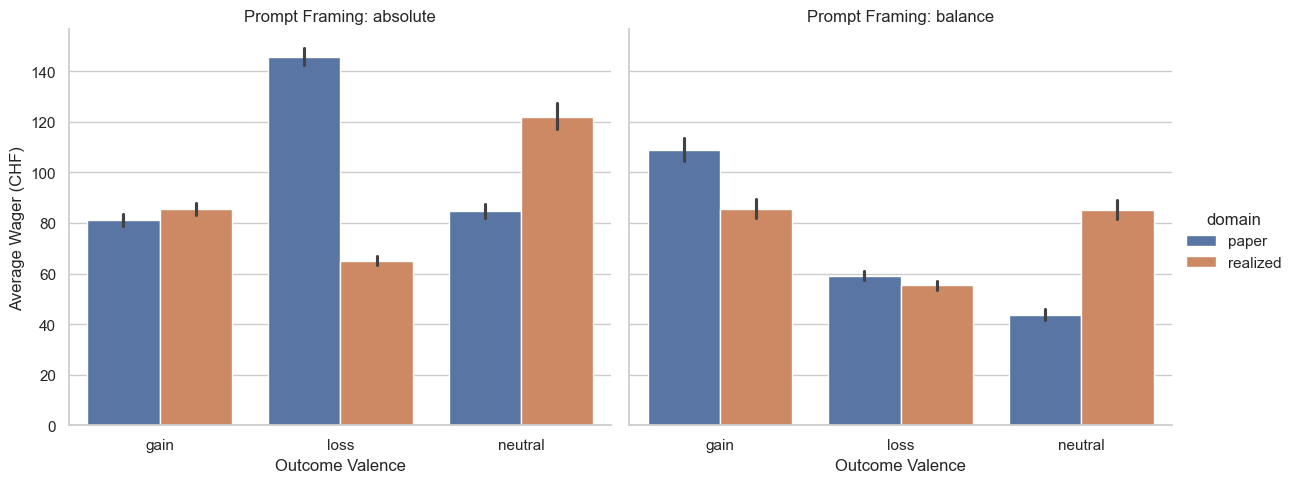

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

g = sns.catplot(
    data=df,
    x="valence",
    y="parsed_wager",
    hue="domain",
    col="prompt_version",
    kind="bar",
    height=5,
    aspect=1.2
)

g.set_axis_labels("Outcome Valence", "Average Wager (CHF)")
g.set_titles("Prompt Framing: {col_name}")

plt.show()